# Category Revenue Analysis
EDA on the relationship between revenue and categories

## Objective
- Do different categories have a significant impact on revenue?
- What are the top categories that contribute to the overall revenue?
- Do sellers with a category specialization make more revenue?

## Approach
- Select the minimum number of top categories that together reach 50% of total revenue. Combine all remaining categories into an Other group. This yields 7 selected categories.
- Visualize counts, sum, mean, and distribution for revenue by category for insights
- Perform statistical test to validate the category effects on revenue
- Analyze seller category count as a proxy for specialization and its relationship to revenue

## Selected Categories for Analysis
Selection is based on cumulative revenue share, selecting the fewest top categories that together reach 50% of total revenue.

  | Category | Total Revenue |
  |-- |-- |
  | health_beauty | 1,407,759.78 |
  | watches_gifts | 1,261,539.41 |
  | bed_bath_table | 1,224,602.68 |
  | sports_leisure | 1,115,766.15 |
  | computers_accessories | 1,031,861.93 |
  | furniture_decor | 873,430.57 |
  | housewares | 756,526.85 |
  | Other | (remaining 66 categories) |

## Key Findings
- The top 7 categories account for 50.6% of total revenue, with health_beauty alone contributing 1.4M. Revenue is concentrated in a small number of high-performing categories.
- Category choice has a meaningful impact on revenue. All categories follow a consistent revenue distribution pattern with no outliers.
- Sellers who focus on fewer categories earn more per item. However, sellers who sell across more categories accumulate higher total revenue, suggesting specialization drives per-item quality while diversification drives volume.

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import kruskal

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

from data.connection import get_connection
from utils.plots import plot_cat, plot_distribution, plot_boxplot_by_group, plot_kde_by_group, plot_hexbin

conn = get_connection()

In [2]:
with open(f"{ROOT}/sql/seller_category.sql") as f:
    sql = f.read()

df = pd.read_sql(sql, conn)

df = df.astype({
    "seller_id": str,
    "seller_state": str,
    "category": str,
    "revenue": float,
})

df.head()

,seller_id,seller_state,category,revenue
0,3504c0cb71d7fa48d967e0e4c94d59d9,SP,housewares,38.71
1,289cdb325fb7e7f891c38608bf9e0962,SP,perfumery,141.46
2,4869f7a5dfa277a7dca6462dcf3b52b2,SP,auto,179.12
3,66922902710d126a0e7d26b0e3805106,MG,pet_shop,72.20
4,2c9e548be18521d1c43cde1c582c6de8,SP,stationery,28.62


## Overview
An initial look across all 73 categories shows a highly concentrated revenue distribution. A small number of categories account for the majority of total revenue, with a long tail of low-volume, low-revenue categories.

### Count, Mean, and Total Revenue by Category

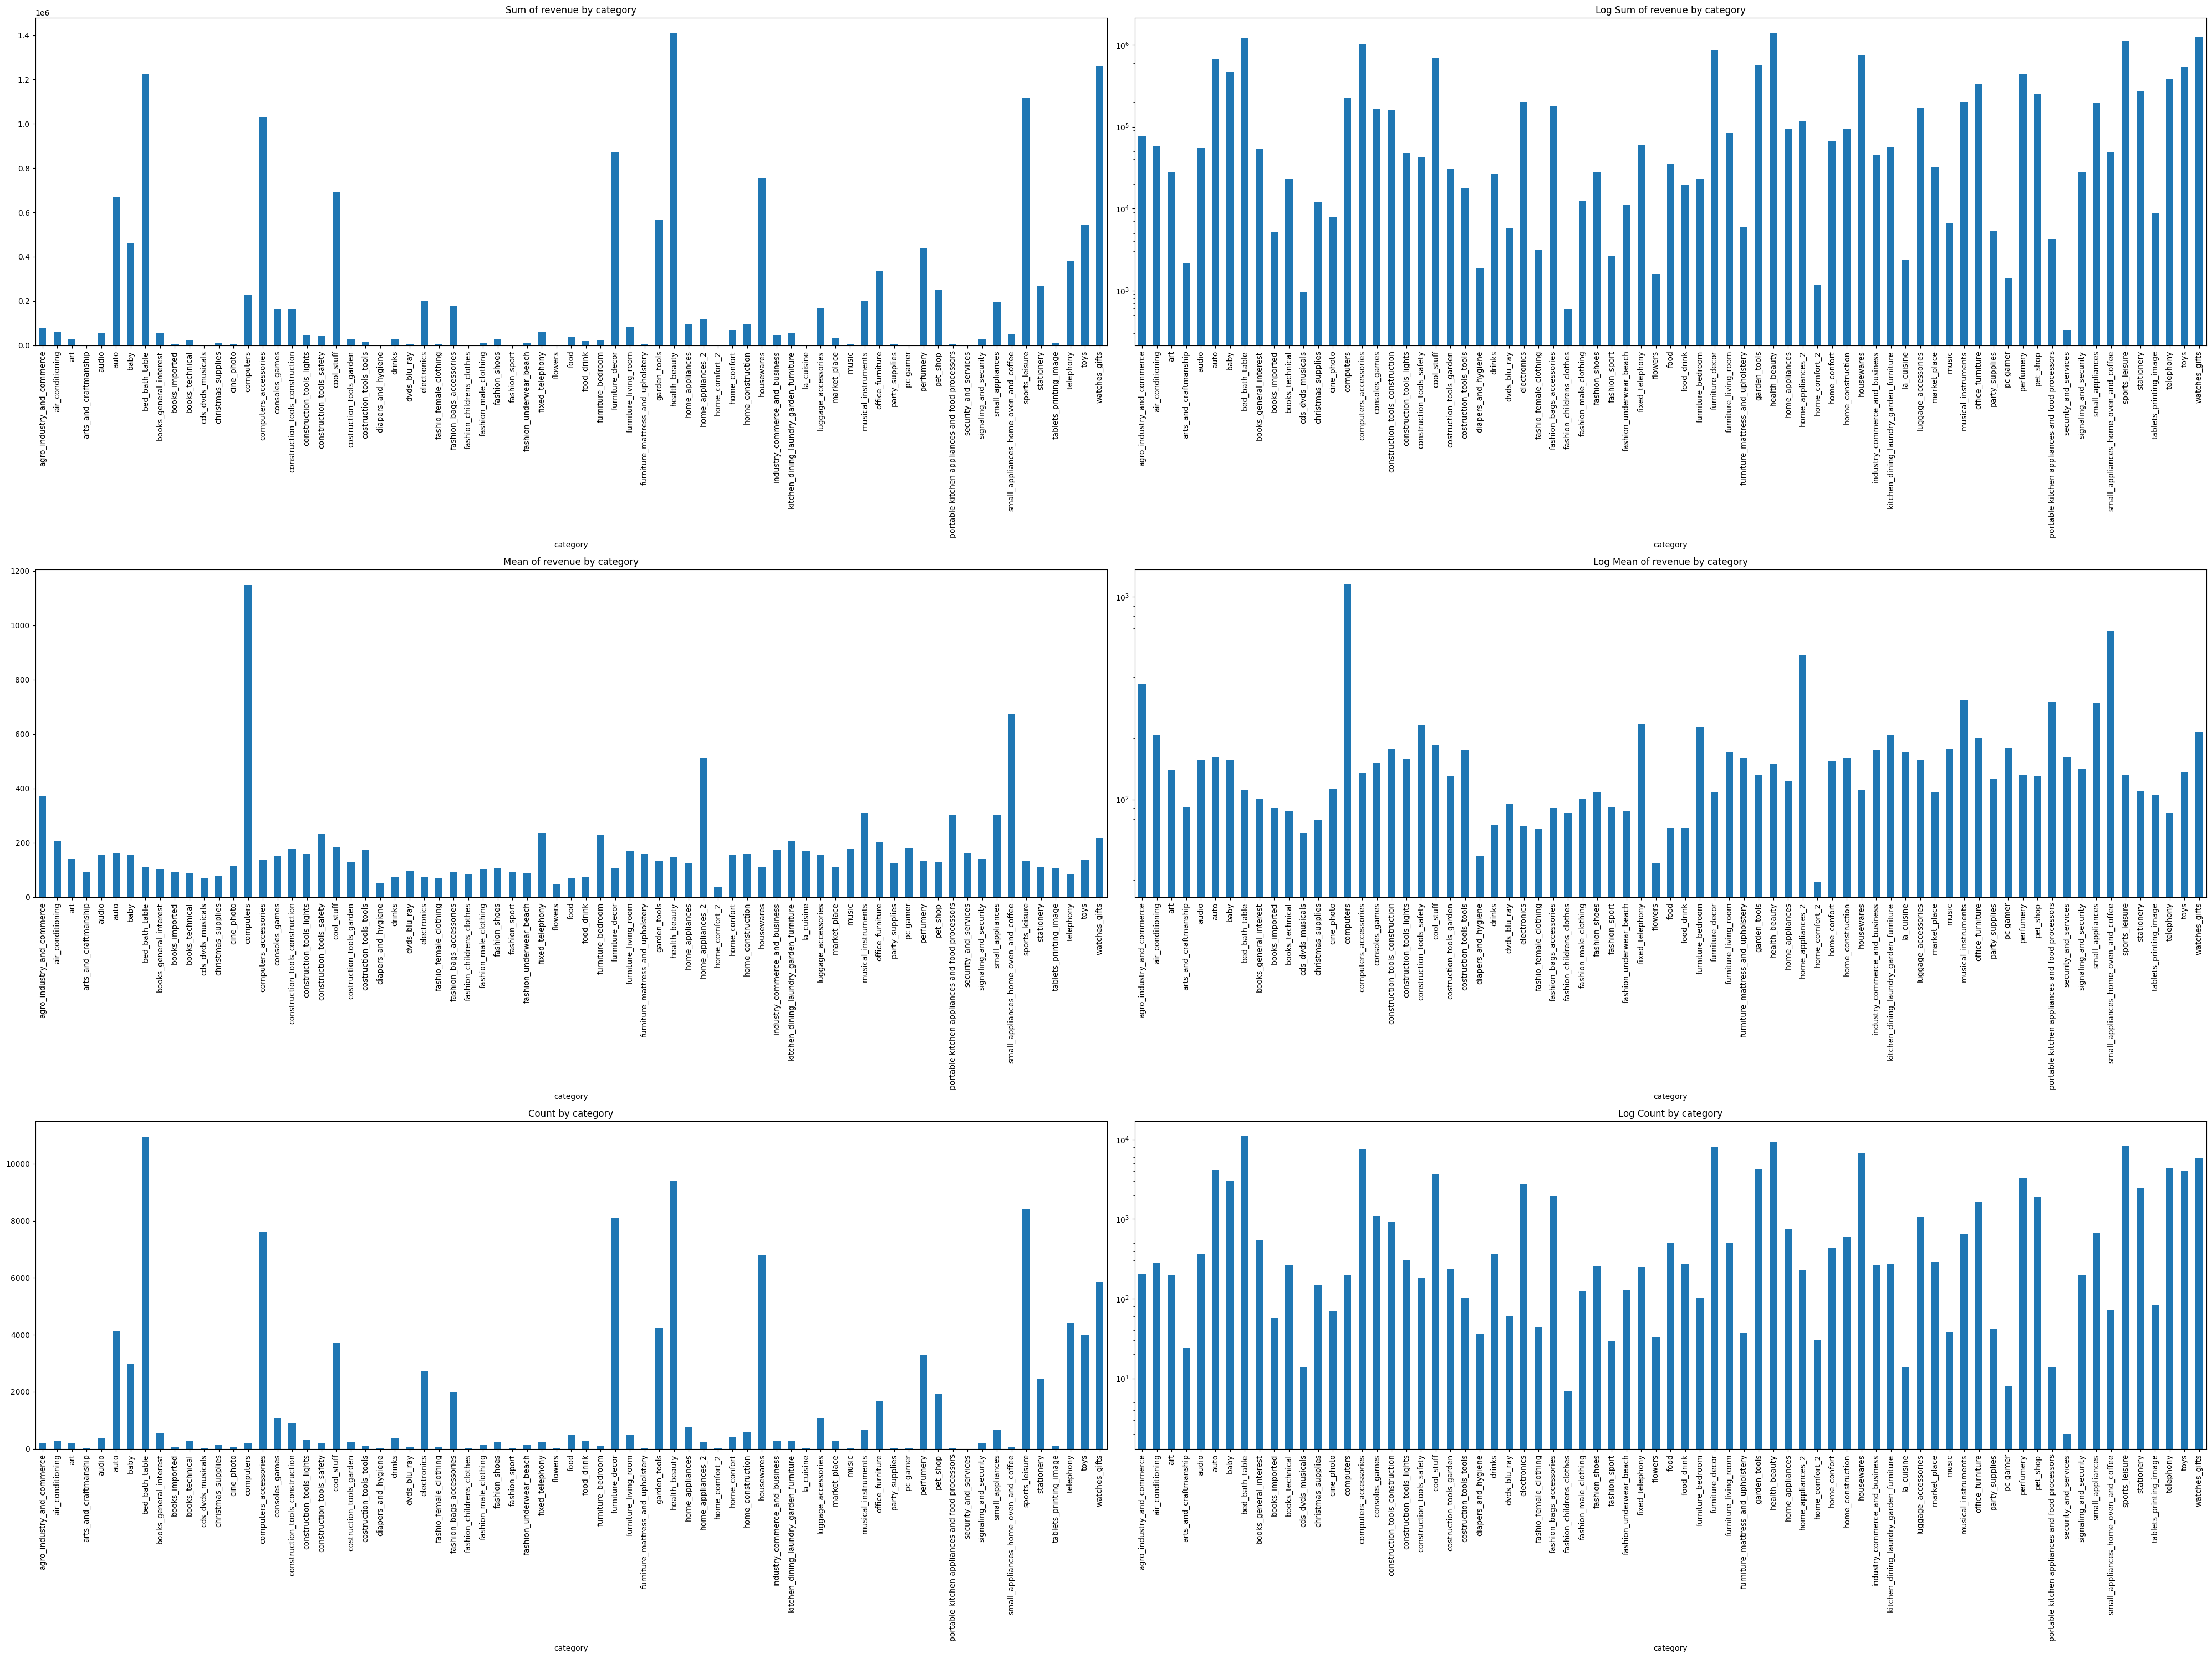

In [3]:
plot_cat(df, "category", "revenue", figsize=(40, 30))

## 1. Revenue by Category

Overview of how revenue is distributed across all categories: total revenue, mean, and item count.

- There are 73 total categories. Revenue drops sharply after the top few. The top 7 categories alone account for 50.6% of total revenue. All remaining 66 categories are grouped into "Other" for analysis.
- The top categories clearly have higher total revenue, but it's hard to tell from plots alone whether the per-item revenue differences are statistically significant. Kruskal-Wallis will be used to test this.

In [4]:
category_stats = (
    df.groupby("category")["revenue"]
    .sum()
    .rename("total_revenue")
    .sort_values(ascending=False)
    .to_frame()
)

### Top Revenue Contributing Categories
Top categories that contribute to 50% of the total revenue share

In [5]:
cumulative_pct = category_stats["total_revenue"].cumsum() / category_stats["total_revenue"].sum() * 100
n_top = int((cumulative_pct <= 50).sum()) + 1

print(f"n_top = {n_top} categories")
print(f"Top {n_top} revenue share: {cumulative_pct.iloc[n_top-1]:.1f}%")
print(f"Other share: {100 - cumulative_pct.iloc[n_top-1]:.1f}%")
print()
print(category_stats.head(n_top)[["total_revenue"]].to_string())

n_top = 7 categories
Top 7 revenue share: 50.6%
Other share: 49.4%

                       total_revenue
category                            
health_beauty             1407759.78
watches_gifts             1261539.41
bed_bath_table            1224602.68
sports_leisure            1115766.15
computers_accessories     1031861.93
furniture_decor            873430.57
housewares                 756526.85


In [6]:
top_categories = category_stats.head(n_top).index
df["category_grouped"] = df["category"].where(df["category"].isin(top_categories), other="Other")
df_no_other = df[df["category_grouped"] != "Other"]

### Revenue by Top 7 Categories and Other
The Other group consolidates 66 remaining categories. Despite covering the majority of categories, Other is roughly comparable in total revenue to the top individual categories, highlighting how concentrated the top 7 are.

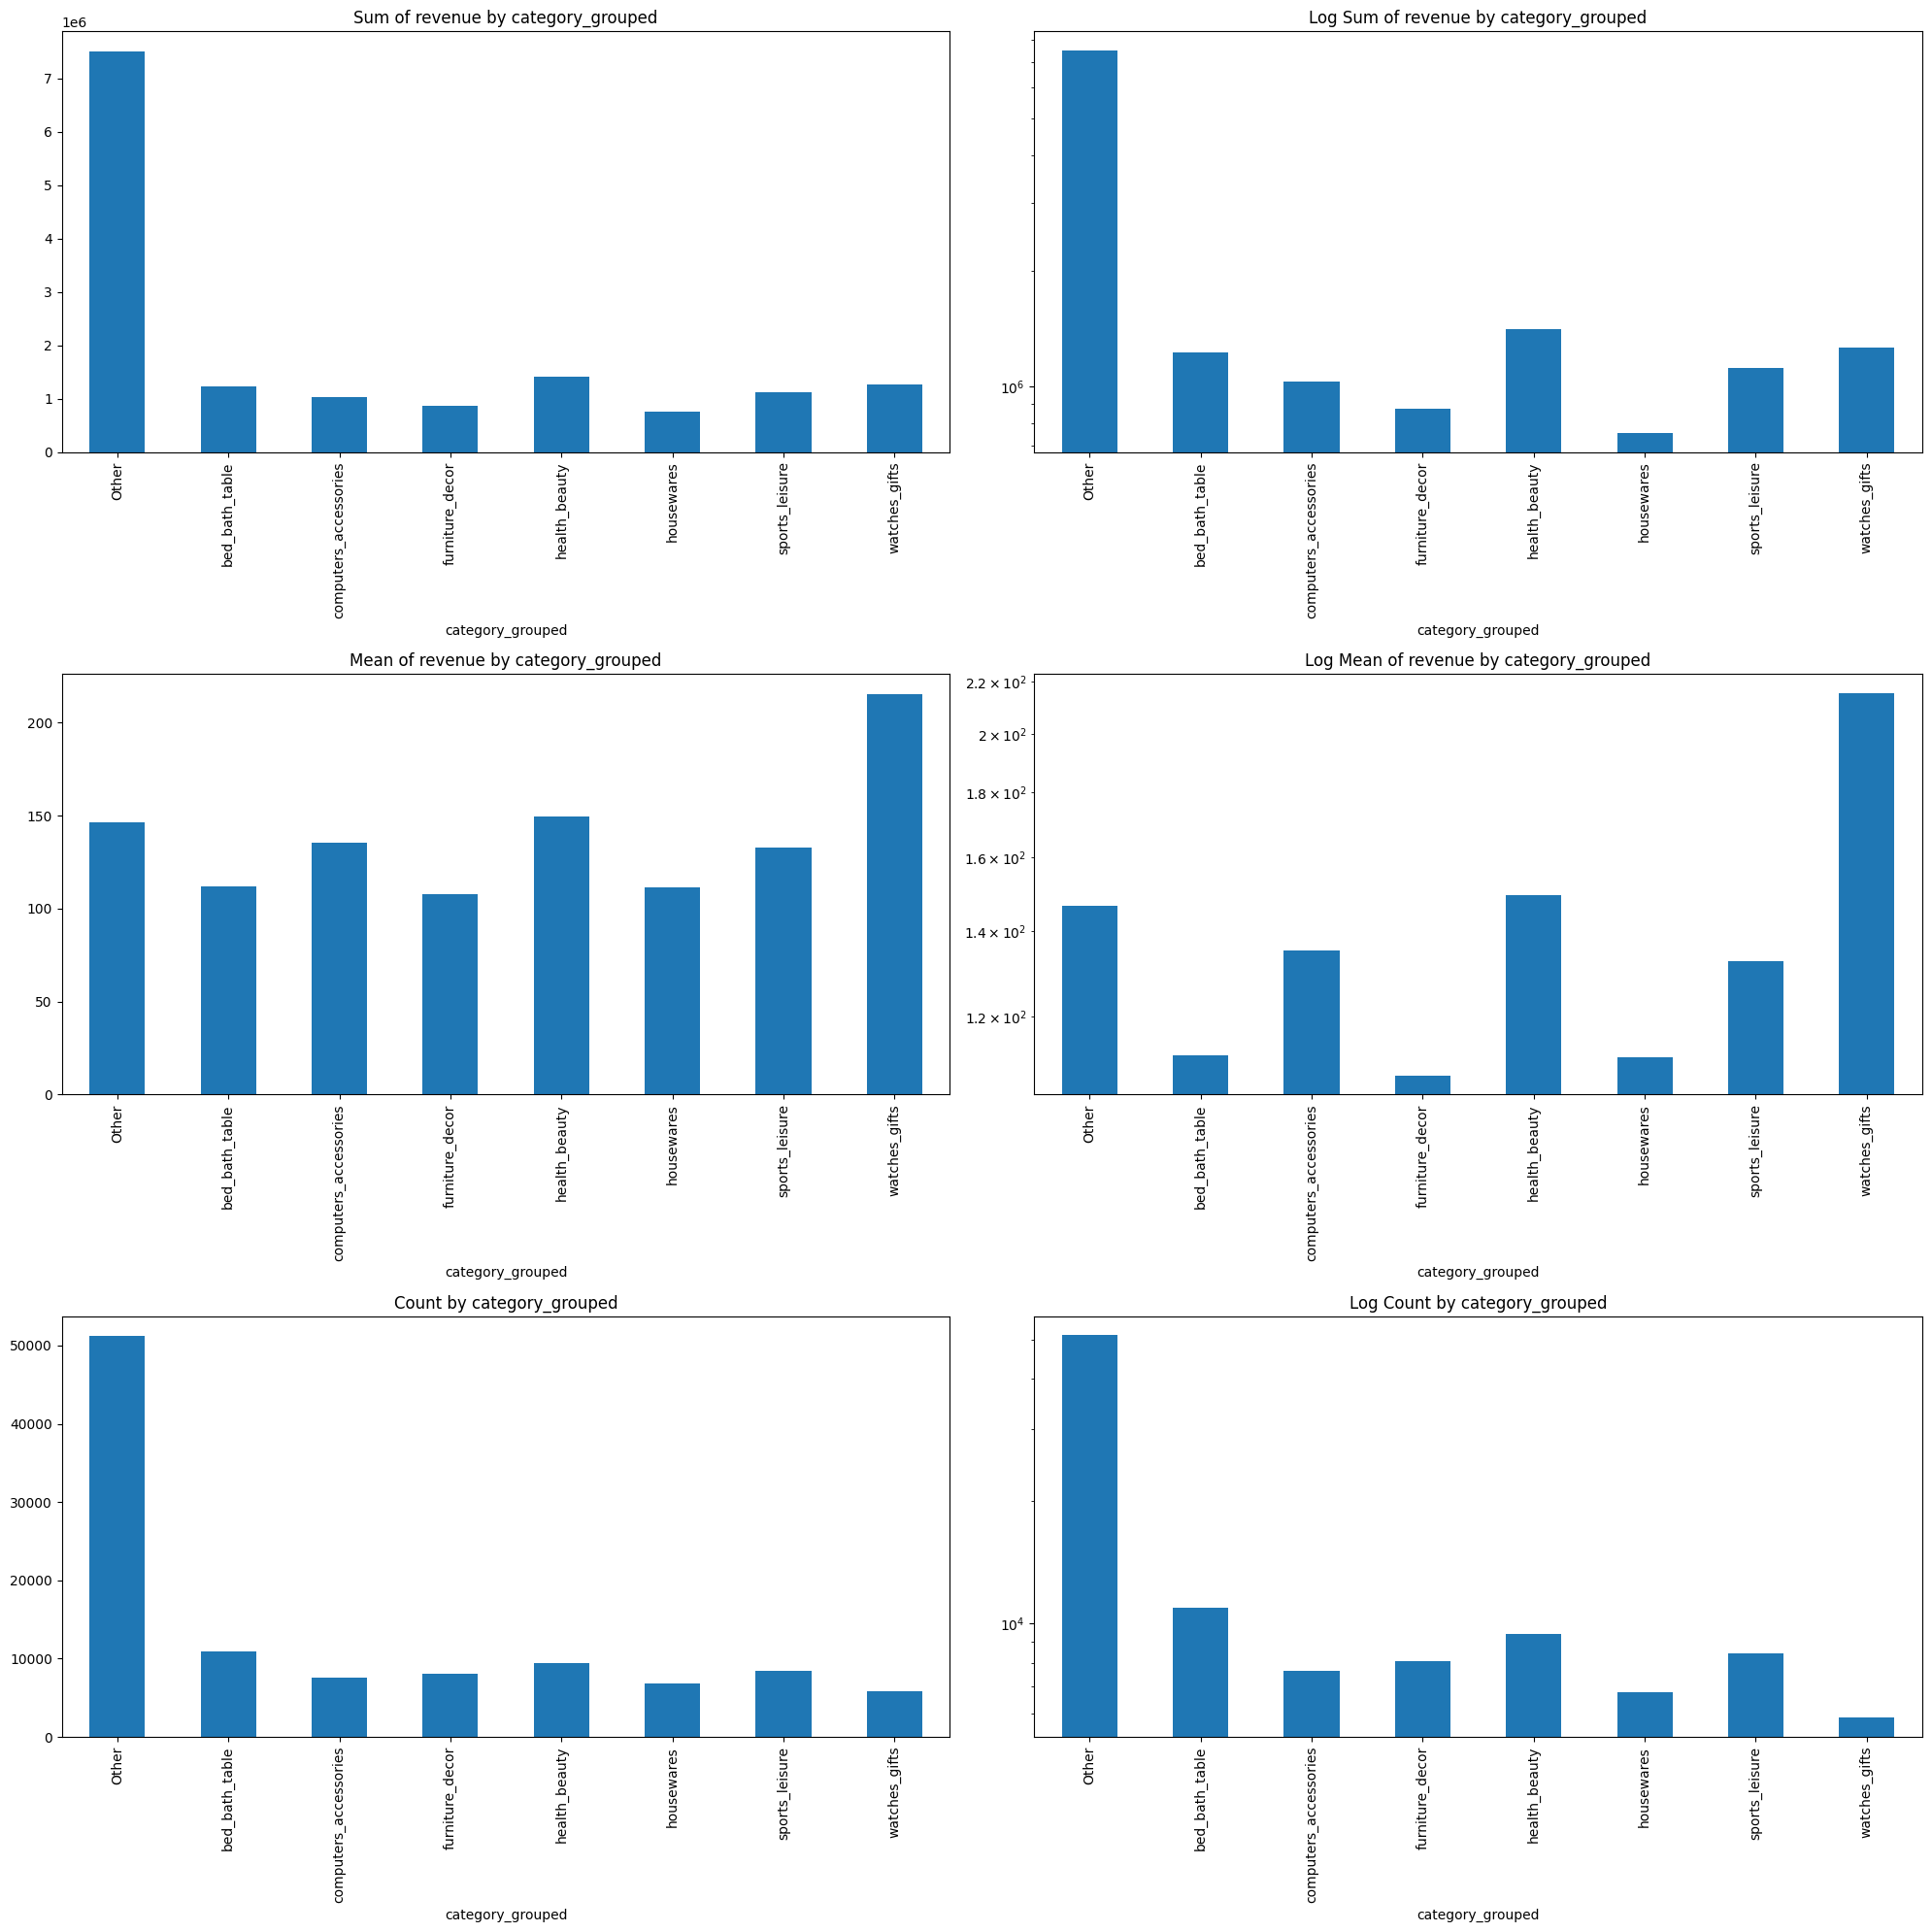

In [7]:
plot_cat(df, "category_grouped", "revenue", figsize=(20, 20))

### Revenue by Top 7 Categories
health_beauty leads in total revenue at 1.4M, with watches_gifts and bed_bath_table close behind. Mean revenue is more similar across the top 7 than total revenue, reflecting differences in order volume.

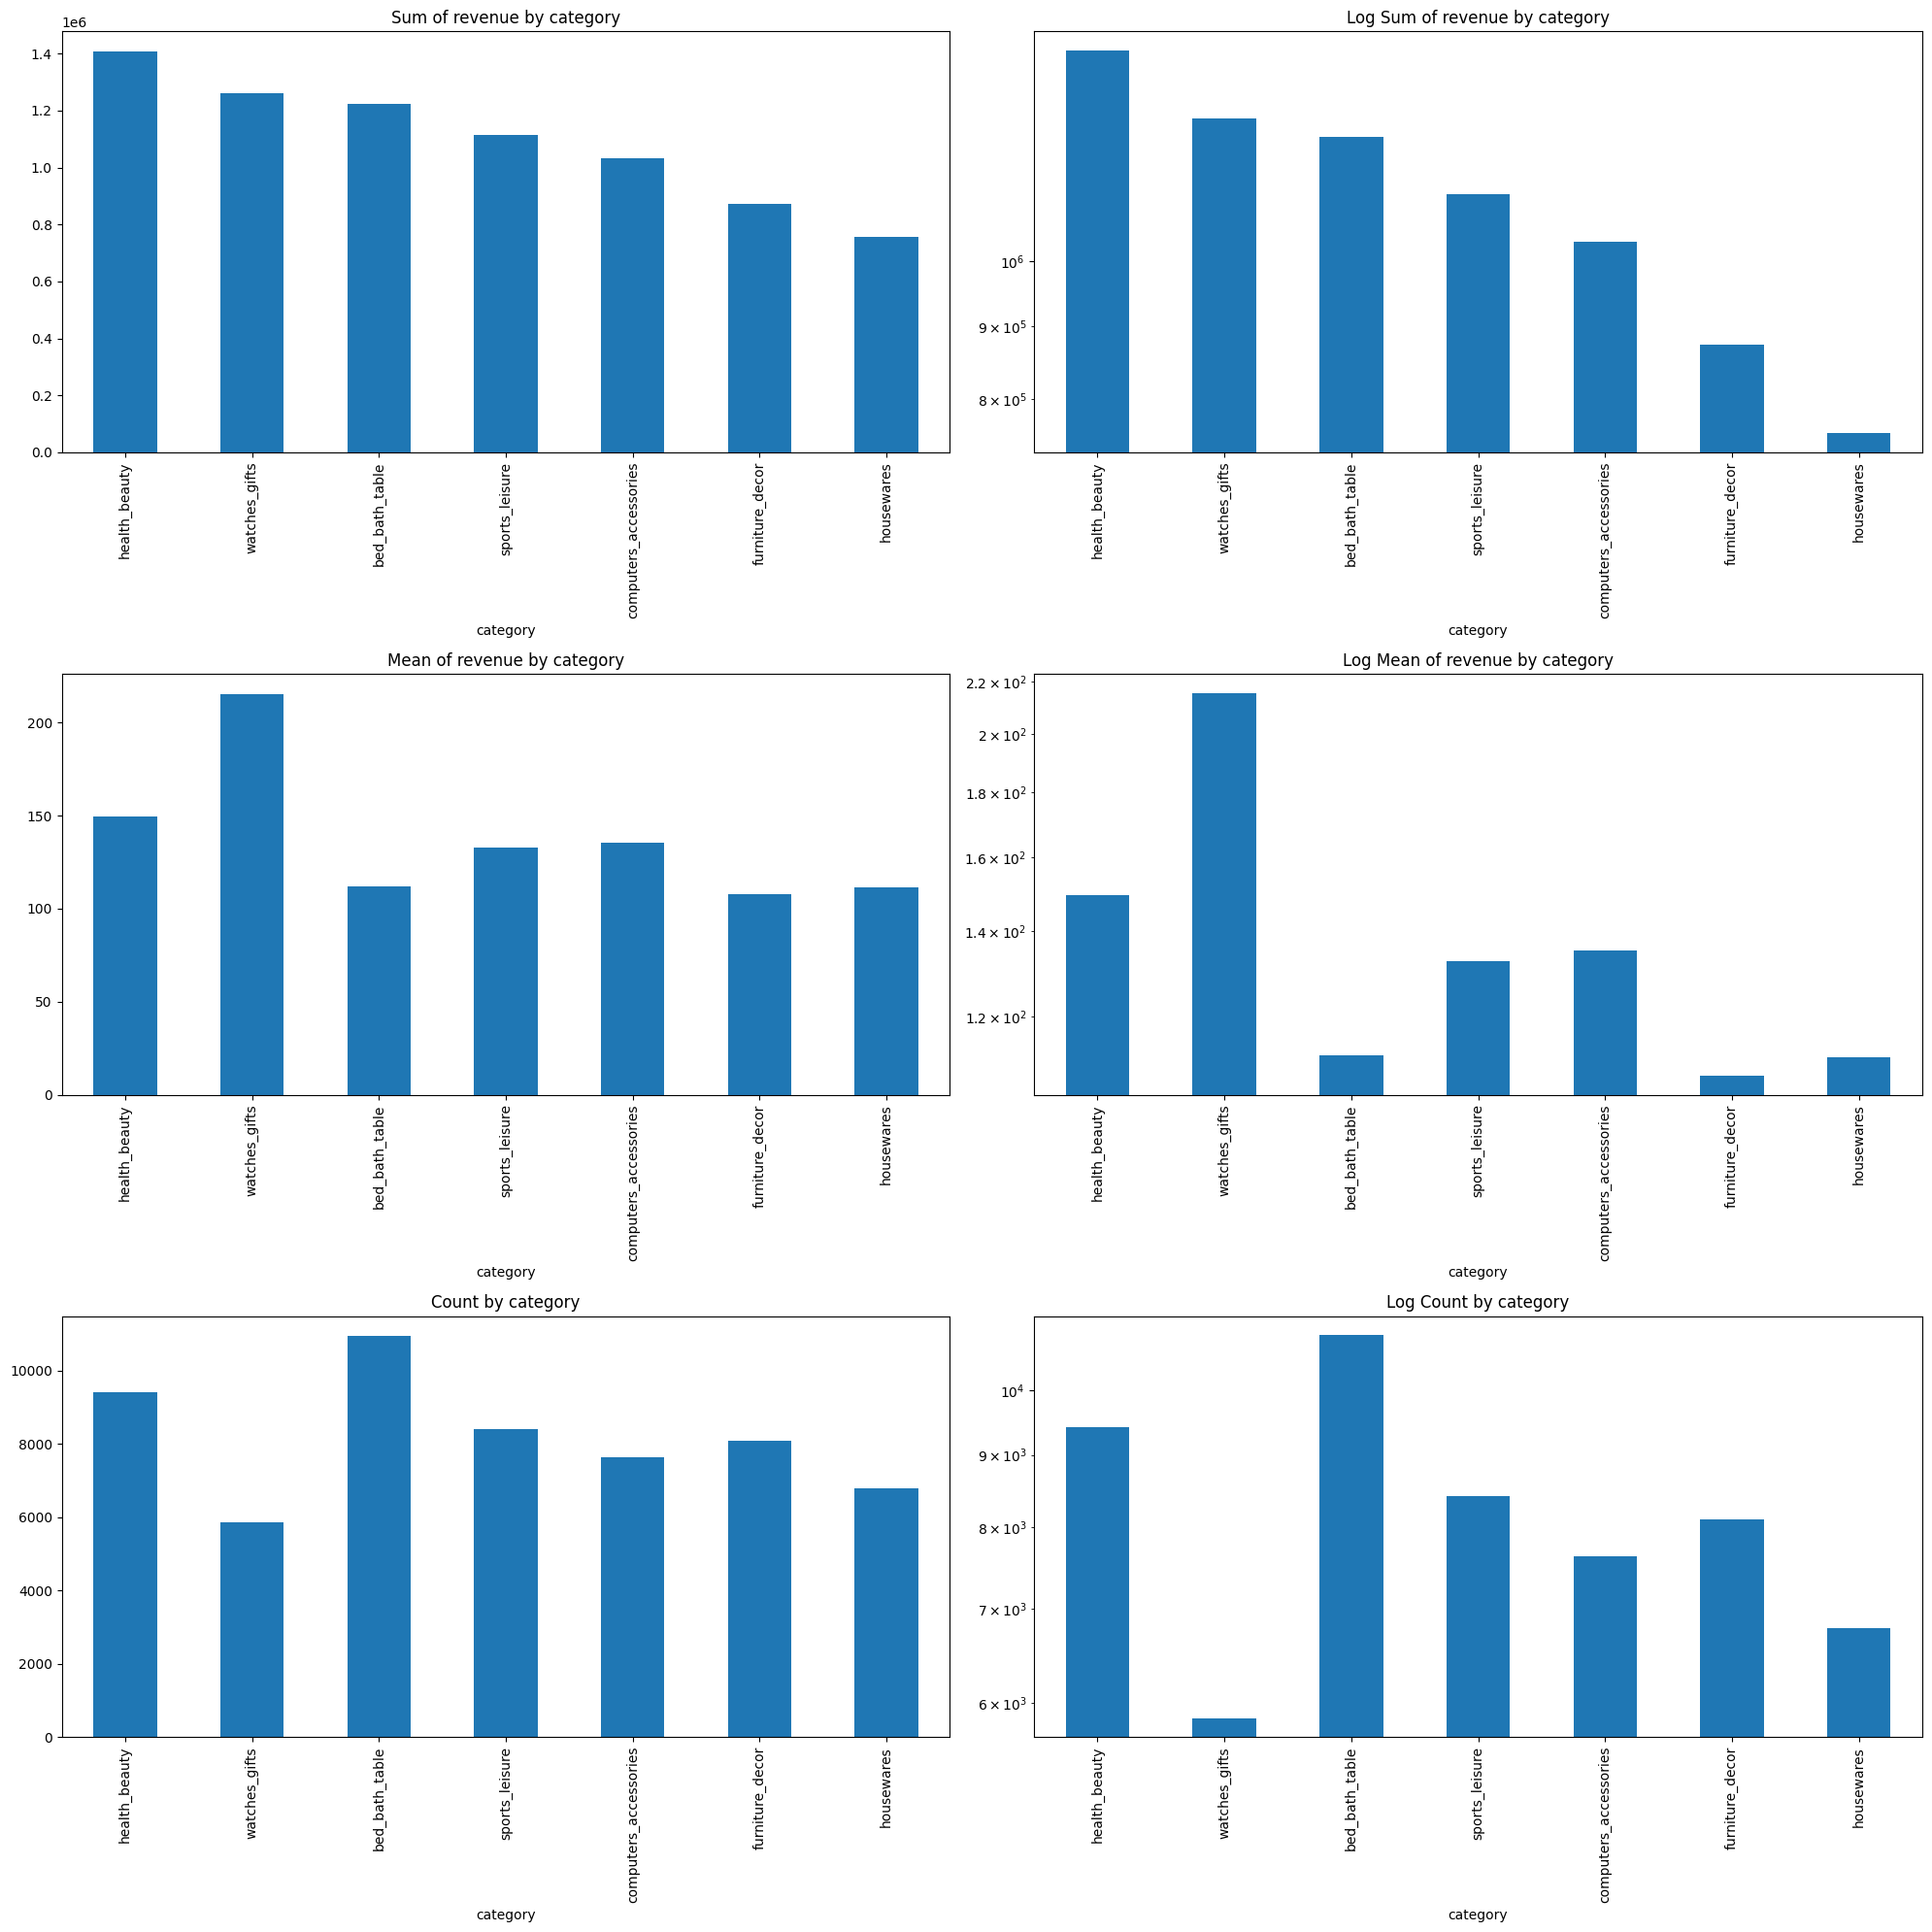

In [8]:
plot_cat(df, "category", "revenue", type="top", n=n_top, rank_by="sum", figsize=(20, 20))

## 2. Revenue Distribution by Category
Compare revenue across different categories. All plots show that they follow the same right-skewed distribution.

- While the shape is consistent, the location of the distribution differs between categories. Categories like computers_accessories and watches_gifts show higher median and mean values compared to housewares and furniture_decor.

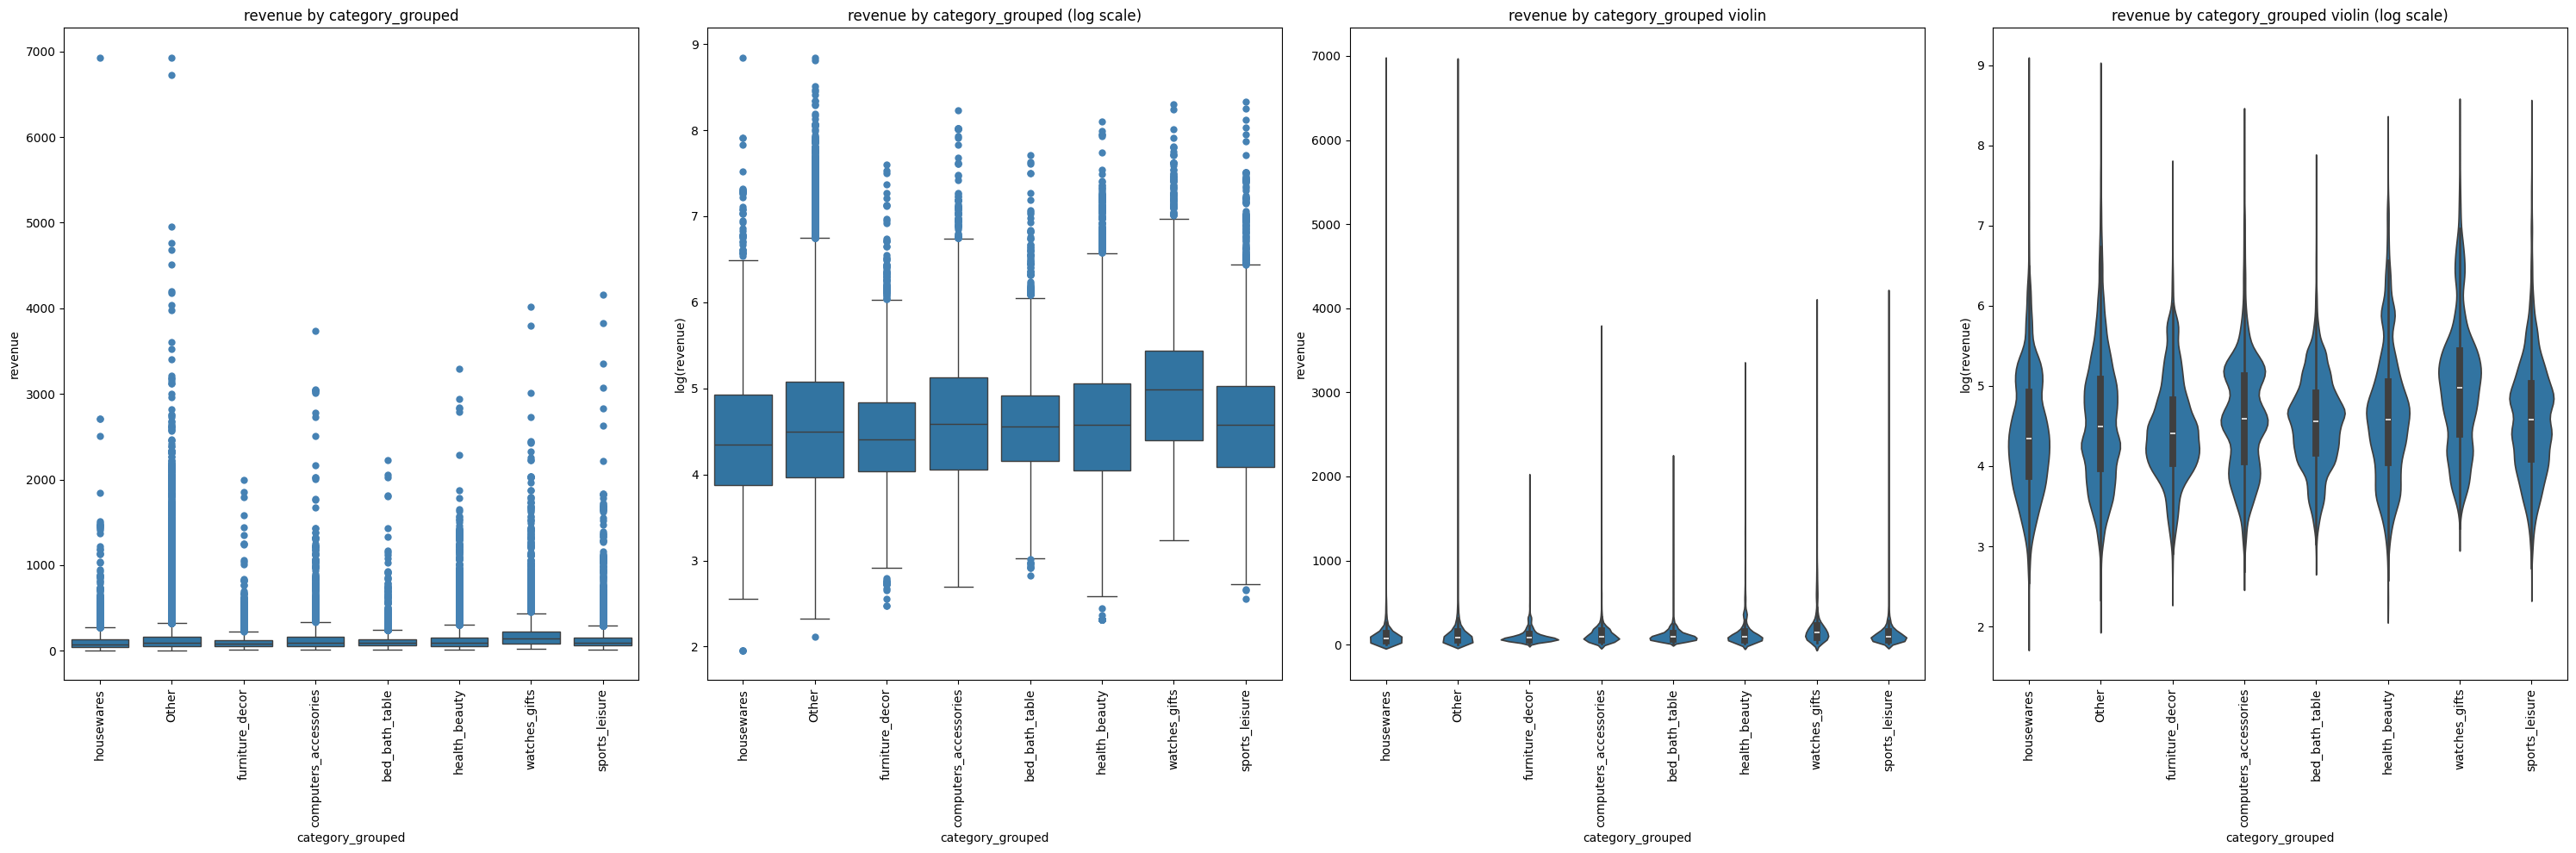

In [9]:
plot_boxplot_by_group(df, "category_grouped", "revenue", figsize=(30, 10))

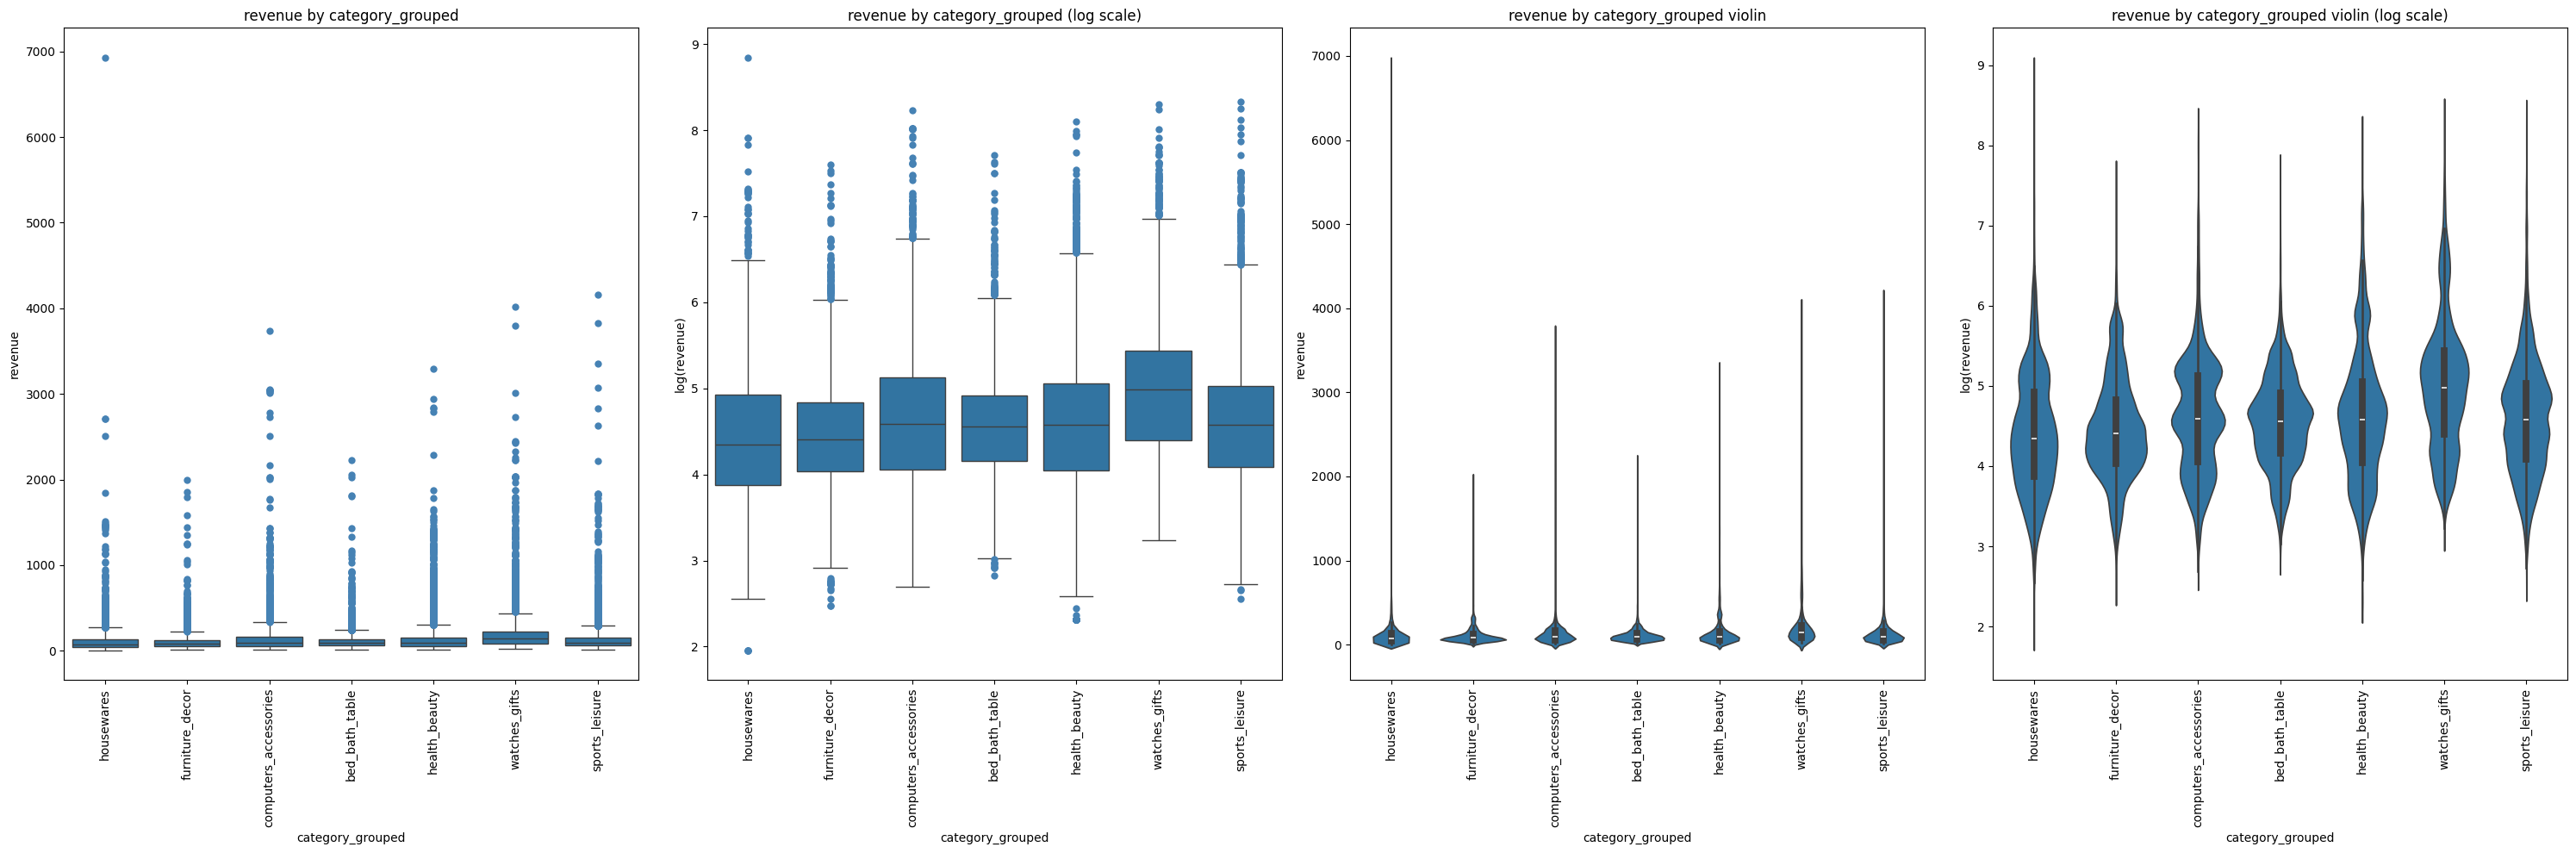

In [10]:
plot_boxplot_by_group(df_no_other, "category_grouped", "revenue", figsize=(30, 10))

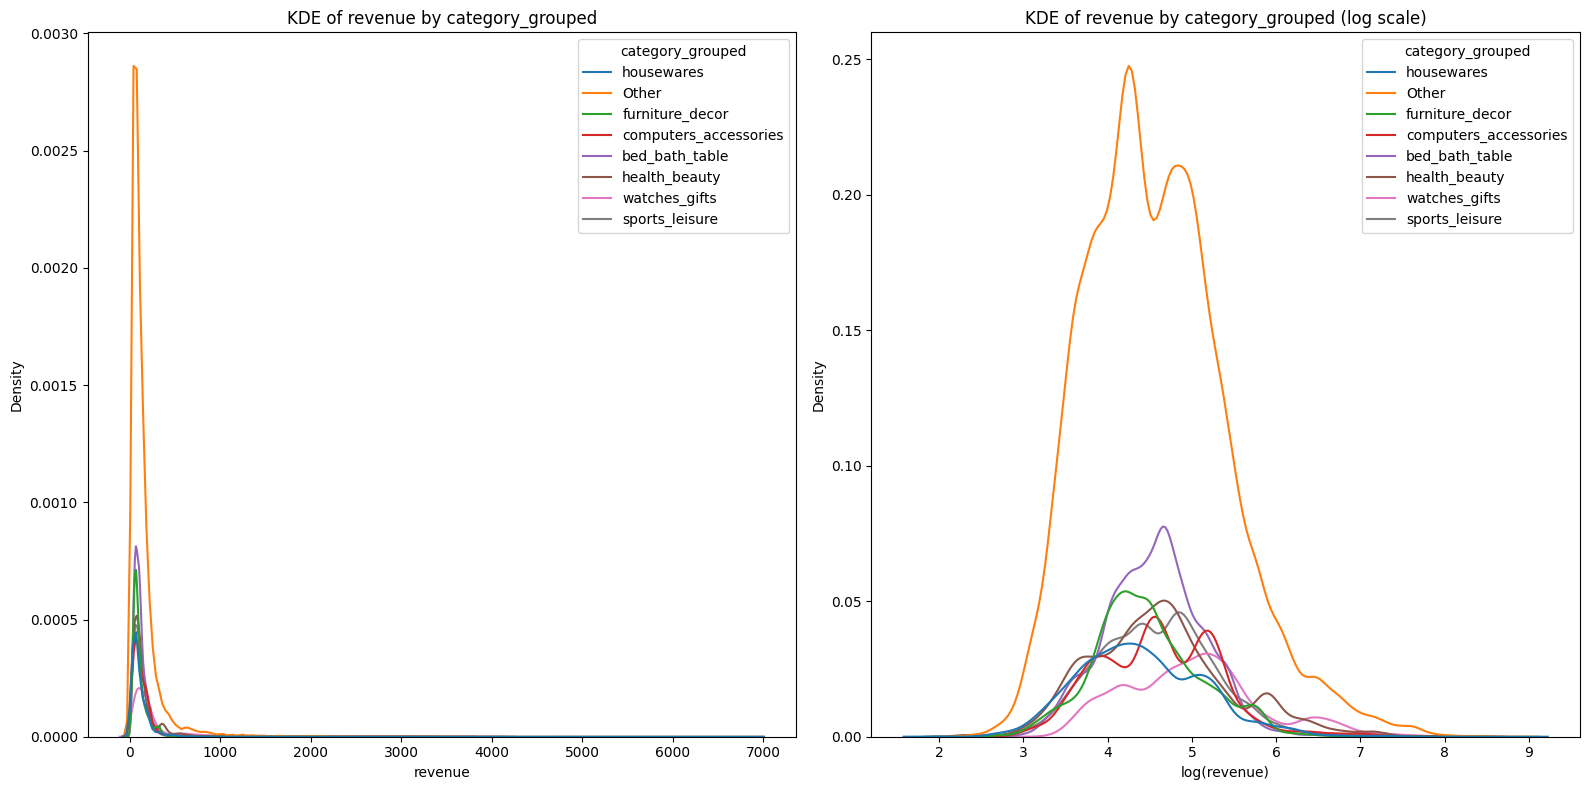

In [11]:
plot_kde_by_group(df, "category_grouped", "revenue", figsize=(16, 8))

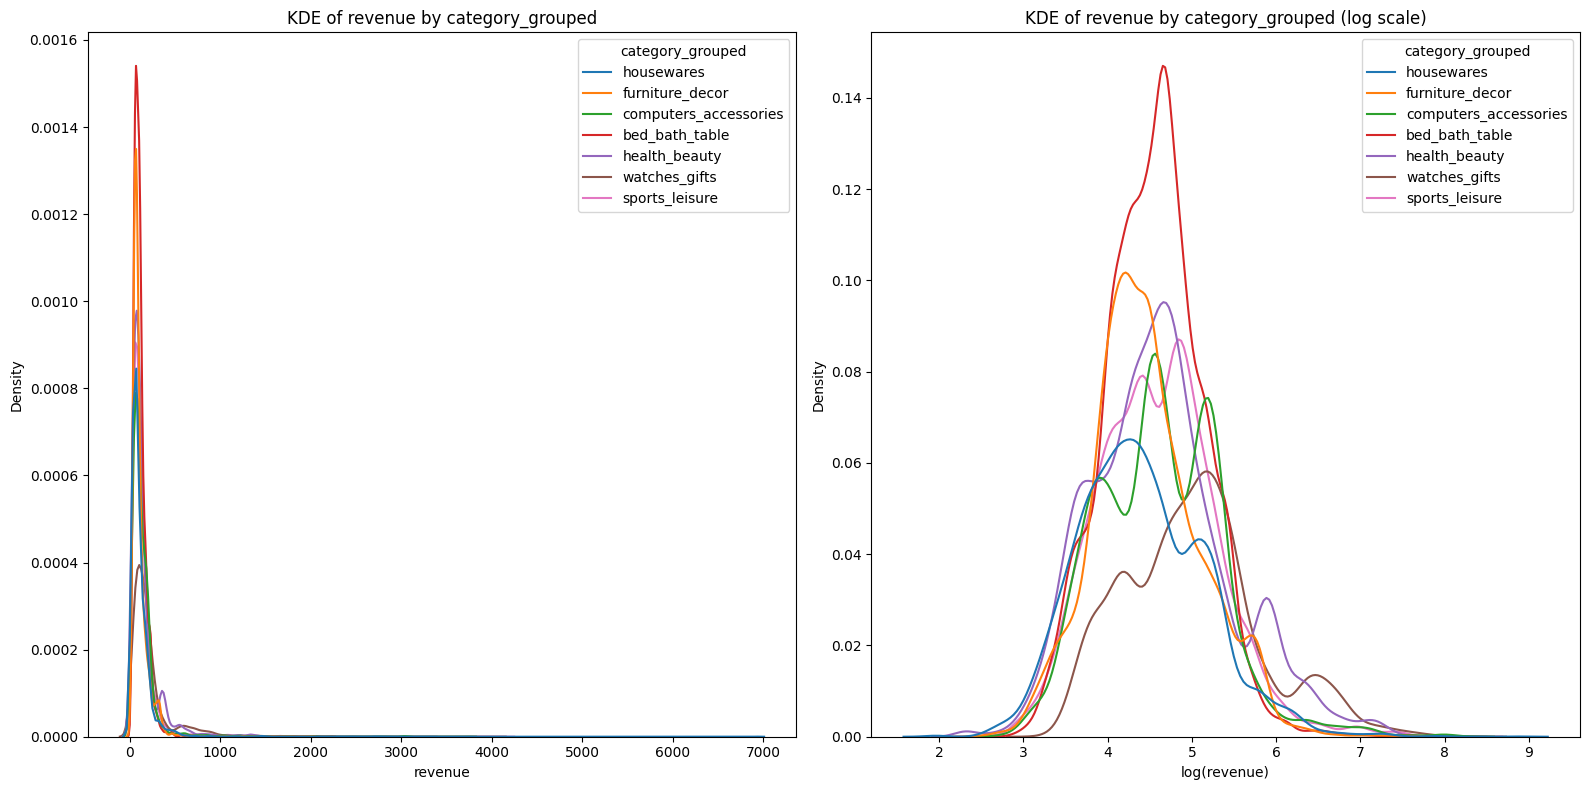

In [12]:
plot_kde_by_group(df_no_other, "category_grouped", "revenue", figsize=(16, 8))

## 3. Category and Revenue Significance Analysis
Kruskal-Wallis shows that there is a significant effect on revenue by category. The test is used here because the data is not normally distributed but follows the same right-skewed shape across all groups. The Other category is not included in this analysis.

- The effect size (epsilon squared = 0.0391) is small but non-trivial, indicating that category explains a modest but real portion of the variance in per-item revenue.

Tested categories include:
- health_beauty
- watches_gifts
- bed_bath_table
- sports_leisure
- computers_accessories
- furniture_decor
- housewares

In [13]:
groups = [g for g in df["category_grouped"].unique() if g != "Other"]
groups_data = [df.loc[df["category_grouped"] == g, "revenue"].values for g in groups]

stat, p = kruskal(*groups_data)

n = sum(len(g) for g in groups_data)
k = len(groups)
epsilon_sq = (stat - k + 1) / (n - k)

print(f"Kruskal-Wallis Test:")
print(f"H statistic : {stat:.4f}")
print(f"p-value: {p:.4f}")
print(f"Significant? : {p < 0.05}")
print(f"Effect Size (epsilon squared): {epsilon_sq:.4f}")

Kruskal-Wallis Test:
H statistic : 2239.3706
p-value: 0.0000
Significant? : True
Effect Size (epsilon squared): 0.0391


## 4. Category Count per Seller
Analyze how the number of different categories sold by a seller relates to their revenue.

- Most sellers operate in a single category. The distribution is heavily right-skewed, with very few sellers selling across more than 5 categories.
- Sellers with lower category counts tend to generate higher average revenue per item, suggesting that specialization is associated with better per-item revenue performance.
- Total revenue tells the opposite story: sellers with more categories accumulate higher total revenue, driven by volume rather than per-item value.

In [14]:
category_count = df.groupby("seller_id")["category"].nunique().rename("category_count")
seller_total = df.groupby("seller_id")["revenue"].sum().rename("total_revenue").reset_index()
seller_avg = df.groupby("seller_id")["revenue"].mean().rename("avg_revenue").reset_index()
seller_total_summary = seller_total.merge(category_count.reset_index(), on="seller_id")
seller_avg_summary = seller_avg.merge(category_count.reset_index(), on="seller_id")

### Category Count per Seller Distribution
The majority of sellers operate in 1 or 2 categories. Very few sellers span more than 5 categories, making the high-category-count group small but potentially distinct in behavior.

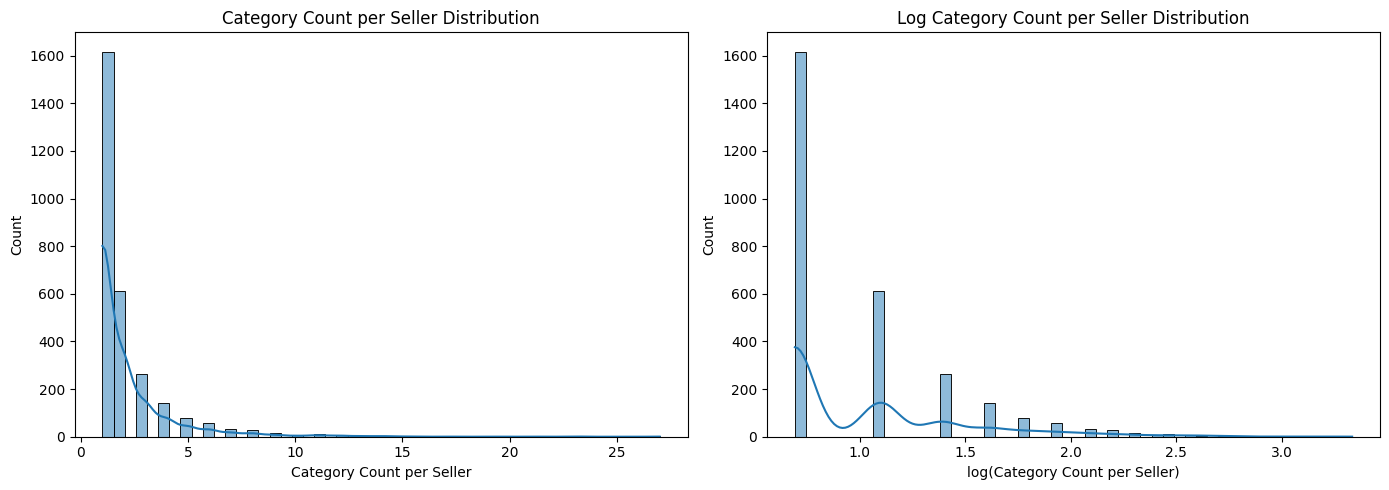

In [15]:
plot_distribution(category_count, label="Category Count per Seller")

### Total Revenue by Category Count Heatmap
Sellers with higher category counts concentrate in higher total revenue bands. This is expected: more categories means more products and higher cumulative revenue, regardless of per-item performance.

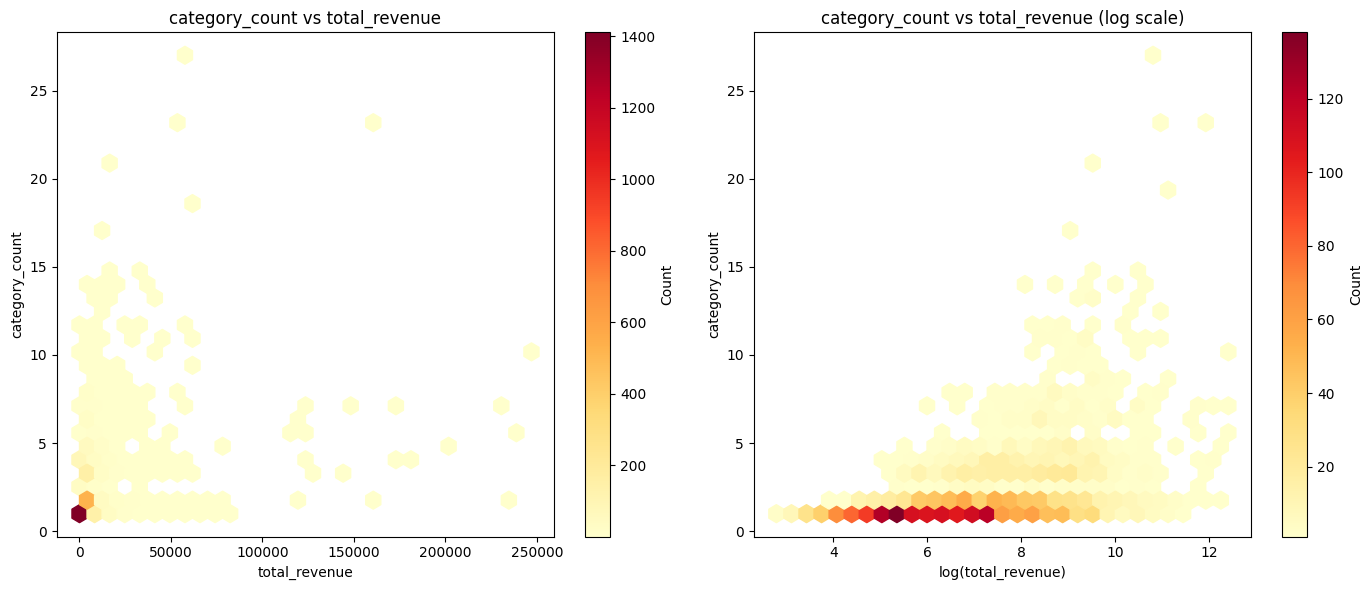

In [16]:
plot_hexbin(seller_total_summary, x_col="total_revenue", y_col="category_count")

### Average Revenue by Category Count Heatmap
Single-category sellers show the strongest average revenue per item. Average revenue declines as category count increases, supporting the specialization hypothesis.

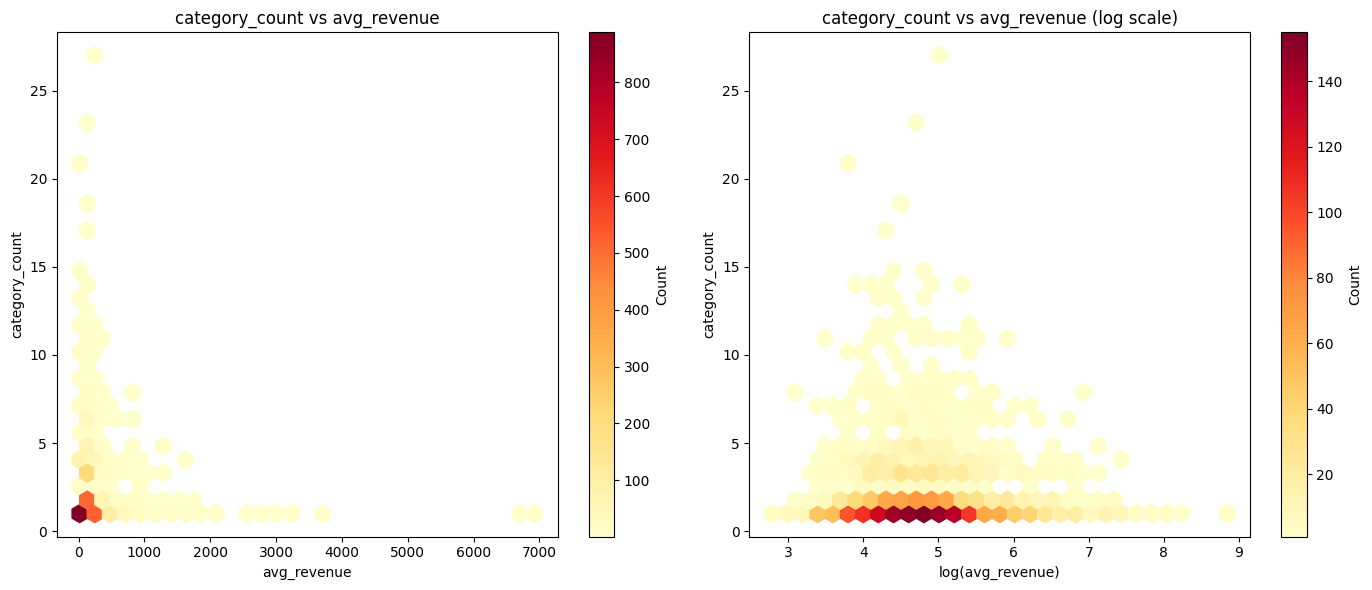

In [17]:
plot_hexbin(seller_avg_summary, x_col="avg_revenue", y_col="category_count")